In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from planetmagfields import Planet
from inversemodel import InverseModel, lcurve_knee
from tqdm import tqdm

# Make figures svg
%config InlineBackend.figure_formats = ['svg']

savefigs = True
if savefigs:
    os.makedirs('figures', exist_ok=True)

# Update x/y label and tick font sizes #Too big, need smaller font sizes
plt.rcParams.update({'font.size': 20})
plt.rcParams.update({'xtick.labelsize': 12})
plt.rcParams.update({'ytick.labelsize': 12})
plt.rcParams.update({'legend.fontsize': 12})

## Read and plot data

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_11551/549132264.py:3: SyntaxWarning: invalid escape sequence '\s'
  df1 = pd.read_csv('./holme_data/Holme_ura.data',sep='\s+')


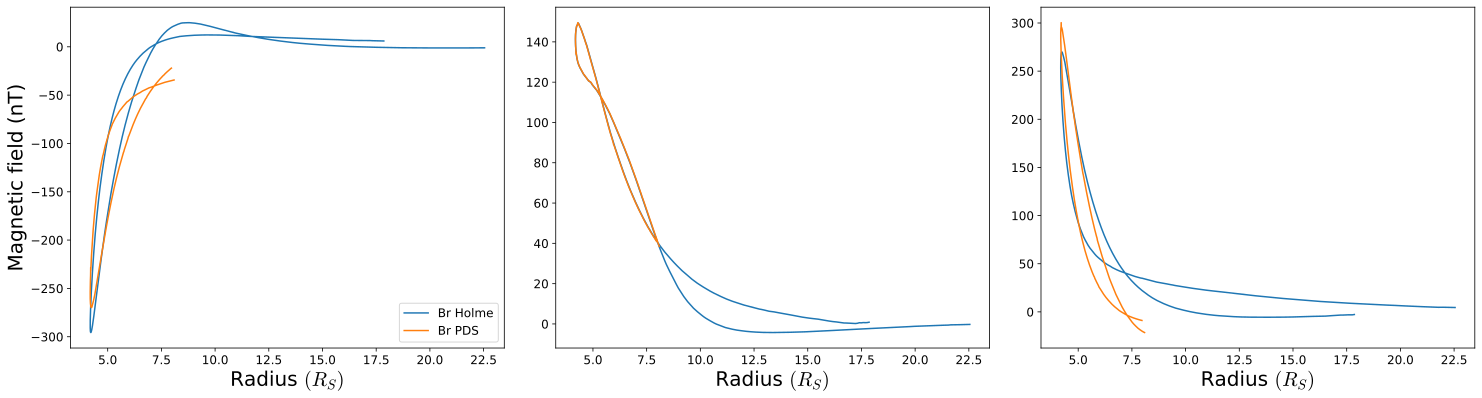

In [7]:
# Let's compare Holme and PDS data

df1 = pd.read_csv('./holme_data/Holme_ura.data',sep='\s+')
df2 = pd.read_csv('./pds_data/uranus48s.csv')

br_dat = -df1['Br'].values/1e4
btheta_dat = -df1['Btheta'].values/1e4
bphi_dat = df1['Bphi'].values/1e4
r = df1['alt'].values
theta = df1['lat'].values
phi = df1['lon'].values

fig, ax = plt.subplots(nrows=1,ncols=3,figsize=(21, 6))

ax[0].plot(r, br_dat, label='Br Holme')
ax[1].plot(r, btheta_dat, label='Btheta Holme')
ax[2].plot(r, bphi_dat, label='Bphi Holme')
ax[0].plot(df2['Radius'], df2['Br'], label='Br PDS')
ax[1].plot(df2['Radius'], df2['Btheta'], label='Btheta PDS')
ax[2].plot(df2['Radius'], df2['Bphi'], label='Bphi PDS')
ax[0].set_xlabel(r'Radius $(R_S)$')
ax[1].set_xlabel(r'Radius $(R_S)$')
ax[2].set_xlabel(r'Radius $(R_S)$')
ax[0].set_ylabel('Magnetic field (nT)')
ax[0].legend()
fig.tight_layout()
plt.show()

## Test forward model

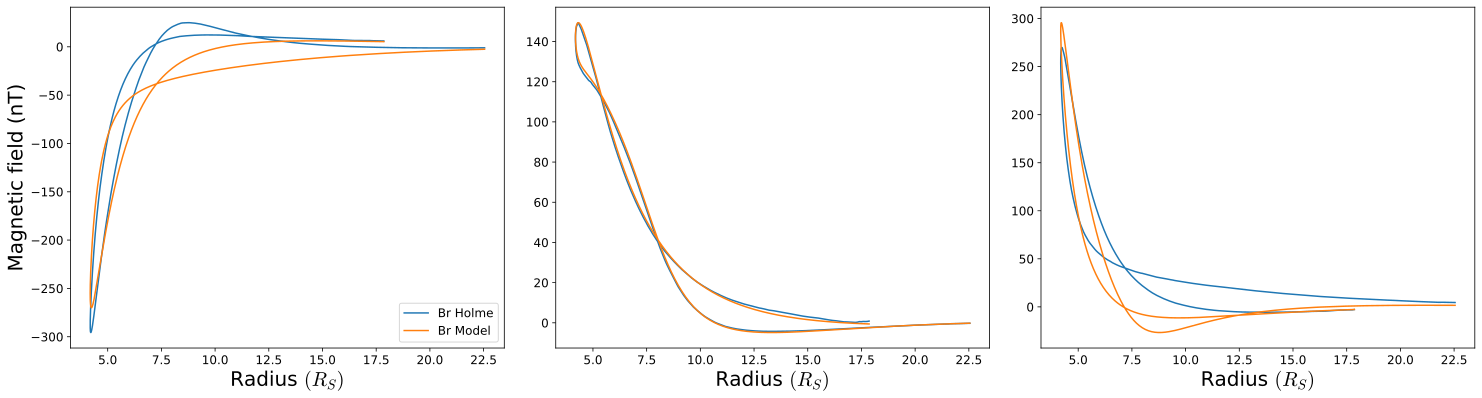

In [14]:
M_fwd = InverseModel(lmax=3,r=df1['alt'],theta=df1['lat'],phi=df1['lon'],br=br_dat,btheta=btheta_dat,bphi=bphi_dat, smoothing_norm='dBr2')
pl = Planet(name='Uranus', model='holme1996', info=False, units='nT')
coeffs_hb = np.zeros(M_fwd.ncoeffs)

for l in range(1, min(M_fwd.lmax,pl.lmax) + 1):
    for m in range(l + 1):
        # Get coefficient from pl using pl's indexing
        coeffs_hb[M_fwd.idx_g[l, m]] = pl.glm[pl.idx[l, m]]

        if m > 0:
            coeffs_hb[M_fwd.idx_h[l, m]] = pl.hlm[pl.idx[l, m]]

# Forward model
b_hb = M_fwd.A @ coeffs_hb
br_hb = b_hb[0::3]
btheta_hb = b_hb[1::3]
bphi_hb = b_hb[2::3]

fig, ax = plt.subplots(nrows=1,ncols=3,figsize=(21, 6))
ax[0].plot(r, br_dat, label='Br Holme')
ax[1].plot(r, btheta_dat, label='Btheta Holme')
ax[2].plot(r, bphi_dat, label='Bphi Holme')
ax[0].plot(r, br_hb, label='Br Model')
ax[1].plot(r, btheta_hb, label='Btheta Model')
ax[2].plot(r, bphi_hb, label='Bphi Model')
ax[0].set_xlabel(r'Radius $(R_S)$')
ax[1].set_xlabel(r'Radius $(R_S)$')
ax[2].set_xlabel(r'Radius $(R_S)$')
ax[0].set_ylabel('Magnetic field (nT)')
ax[0].legend()
fig.tight_layout()
plt.show()


## Inverse Modeling

## Find optimal $\alpha$

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:06<00:00, 15.85it/s]


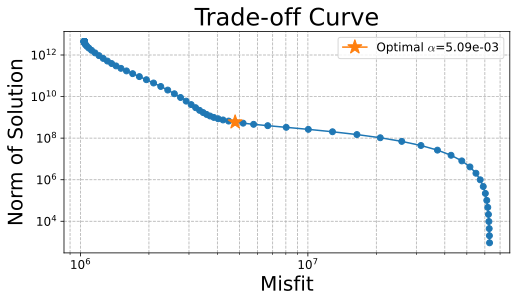

In [41]:
# # Create model
M = InverseModel(lmax=3, r=r, theta=theta, phi=phi,
                 br=br_dat,
                 btheta=btheta_dat,
                 bphi=bphi_dat,
                 smoothing_norm='Br2',
                 include_external=True,
                 a=1,b=0.8,c=0.7)

# Define alpha range
alpha_arr = np.logspace(-15, 2, 100)

# Plot trade-off curve
misfit_arr = []
norm_arr = []
for alpha in tqdm(alpha_arr):
    M.solve(alpha=alpha)
    misfit_arr.append(M.misfit)
    norm_arr.append(M.norm_value)

optimal_idx, optimal_alpha, curvature = lcurve_knee(alpha_arr, misfit_arr, norm_arr, trim=4)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 4))
ax.loglog(misfit_arr, norm_arr, marker='o')
ax.loglog(misfit_arr[optimal_idx], norm_arr[optimal_idx], marker='*', markersize=15, label=r'Optimal $\alpha$=%.2e' % optimal_alpha)
ax.legend()
ax.set_xlabel('Misfit')
ax.set_ylabel('Norm of Solution')
ax.set_title('Trade-off Curve')
ax.grid(True, which='both', ls='--')
if savefigs:
    plt.savefig('figures/tradeoff_curve_holme.png', dpi=300, bbox_inches='tight')
plt.show()

M.solve(alpha=optimal_alpha)

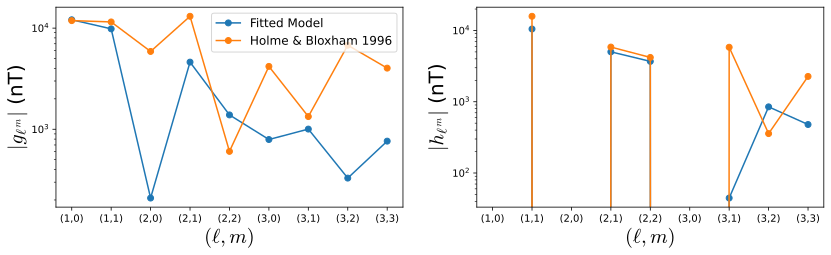

In [32]:
pl = Planet(name='Uranus', model='holme1996', info=False, units='nT')
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(12,4))
for i in [0,1]:
    if i == 0:
        coeff = M.glm[:9]
        coeff_ref = pl.glm[1:10]
        ylabel = r'$|g_{\ell^m}|$ (nT)'
    if i == 1:
        coeff = M.hlm[:9]
        coeff_ref = pl.hlm[1:10]
        ylabel = r'$|h_{\ell^m}|$ (nT)'

    ax[i].plot(np.abs(coeff),'-o',label='Fitted Model')
    ax[i].plot(np.abs(coeff_ref),'-o',label='Holme & Bloxham 1996')
    ax[i].set_yscale('log')
    ax[i].set_xlabel(r'$(\ell,m)$',fontsize=20)
    ax[i].set_xticks(np.arange(9))
    ax[i].set_xticklabels(['(1,0)','(1,1)','(2,0)','(2,1)','(2,2)','(3,0)','(3,1)','(3,2)','(3,3)'])
    ax[i].tick_params(axis='both', which='major', labelsize=10)
    ax[i].set_ylabel(ylabel,fontsize=20)

ax[0].legend()
fig.tight_layout()
if savefigs:
    plt.savefig('figures/uranus_fitted_gauss_coefficients_holme.png', dpi=300)
plt.show()

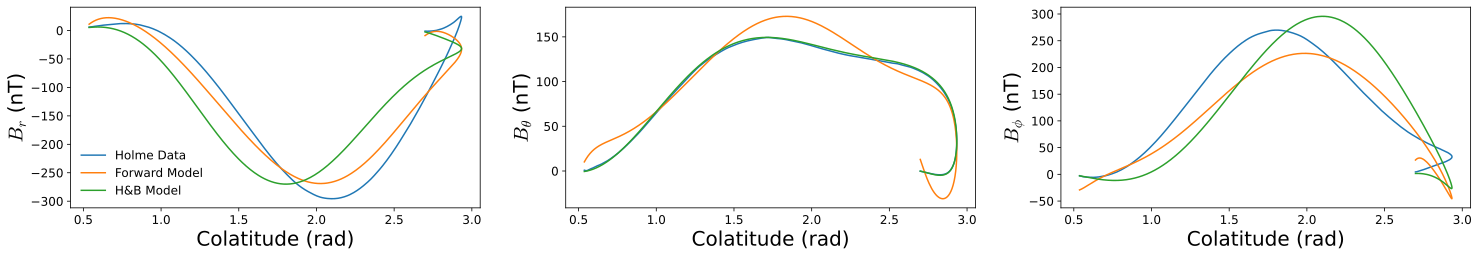

In [44]:
#Test both forward models:

b = np.real(M.A @ M.coeffs)
br = b[0::3]
btheta = b[1::3]
bphi = b[2::3]

# # Rearrange Holme and Bloxham 1996 coefficients into same format as M.coeffs
pl = Planet(name='Uranus', model='holme1996', info=False, units='nT')
coeffs_hb = np.zeros(M.ncoeffs)

for l in range(1, min(M.lmax,pl.lmax) + 1):
    for m in range(l + 1):
        # Get coefficient from pl using pl's indexing
        coeffs_hb[M.idx_g[l, m]] = pl.glm[pl.idx[l, m]]

        if m > 0:
            coeffs_hb[M.idx_h[l, m]] = pl.hlm[pl.idx[l, m]]

# Forward model
b_hb = M.A @ coeffs_hb
br_hb = b_hb[0::3]
btheta_hb = b_hb[1::3]
bphi_hb = b_hb[2::3]

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(21, 4), sharex=True)
ax[0].plot(theta, br_dat, label='Holme Data')
ax[0].plot(theta, br, label='Forward Model')
ax[0].plot(theta, br_hb, label='H&B Model')
ax[0].set_ylabel(r'$B_r$ (nT)')
ax[0].set_xlabel('Colatitude (rad)')
ax[0].legend(frameon=False)
ax[1].plot(theta, btheta_dat, label='Holme Data')
ax[1].plot(theta, btheta, label='Forward Model')
ax[1].plot(theta, btheta_hb, label='H&B Model')
ax[1].set_ylabel(r'$B_\theta$ (nT)')
ax[1].set_xlabel('Colatitude (rad)')
ax[2].plot(theta, bphi_dat, label='Holme Data')
ax[2].plot(theta, bphi, label='Forward Model')
ax[2].plot(theta, bphi_hb, label='H&B Model')
ax[2].set_ylabel(r'$B_\phi$ (nT)')
ax[2].set_xlabel('Colatitude (rad)')
fig.tight_layout()

if savefigs:
    plt.savefig('figures/uranus_forward_model_holme.png', dpi=300)
plt.show()

In [34]:
# Print external coefficients:

print(f"External field coefficients:")
print(f"  G10 = {M.G10:.2f} nT")
print(f"  G11 = {M.G11:.2f} nT")
print(f"  H11 = {M.H11:.2f} nT")

External field coefficients:
  G10 = -0.49 nT
  G11 = 29.36 nT
  H11 = 0.63 nT


In [35]:
# Compare actual values
print("Model glm:", M.glm)
print("Holme & Bloxham glm:", pl.glm[1:])
print("Model hlm:", M.hlm)
print("Holme & Bloxham hlm:", pl.hlm[1:])

Model glm: [ 1.20882178e+04  9.83271383e+03  2.09068786e+02  4.61120655e+03
  1.38645469e+03 -7.92179687e+02 -1.00429933e+03 -3.29204006e+02
 -7.63436077e+02  8.47044461e+01  2.32268406e+01 -1.76414748e+02
 -1.17177515e+02 -1.38201996e+02  5.44511178e+00  1.97159183e+01
  5.24588053e+01  2.34479765e+01  9.61696030e+00  1.25786467e+01
 -9.33767076e-01 -2.68688930e+00 -2.41798129e+00  6.09386507e+00
  9.82856197e+00  4.49101705e+00  6.49574170e+00 -1.23485934e-01
  3.82079343e-02 -9.18776202e-01 -1.98607839e+00 -1.81008722e+00
  3.06420403e-01 -3.46280206e-01  4.10062185e-01  9.76950484e-03
  1.13992053e-02  1.41441356e-01  1.15532096e-01 -1.56913929e-01
 -5.80914360e-01 -2.52780270e-01 -2.77020430e-01 -1.62569429e-01
  7.43139696e-03 -5.91546337e-04  1.87416265e-03  2.61180959e-02
  8.44884523e-02  9.98322685e-02 -1.34067586e-02 -1.73191397e-02
 -1.96245332e-02 -3.46688115e-02 -1.38642028e-03  7.51073566e-04
 -1.99266935e-03 -4.00037033e-03 -8.51969113e-03  4.74429850e-03
  2.62449247e-

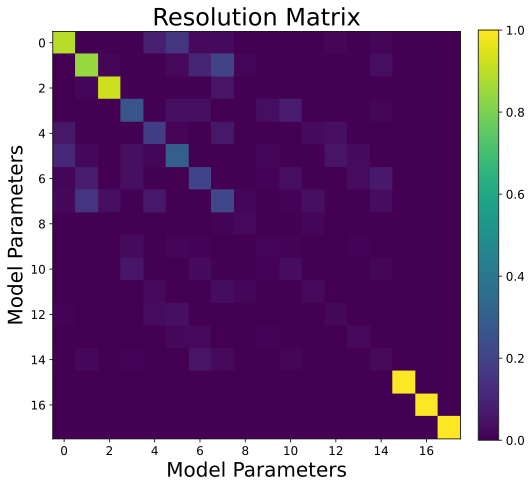

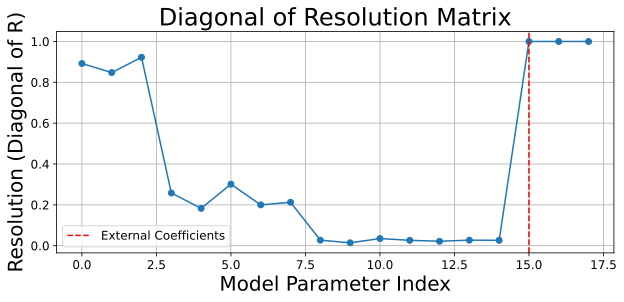

In [43]:
# Plot resolution matrix like Holme & Bloxham 1996
M.resolution_matrix(alpha=optimal_alpha)
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 8))
im = ax.imshow(M.R, cmap='viridis', vmin=0, vmax=1)
ax.set_xlabel('Model Parameters')
ax.set_ylabel('Model Parameters')
ax.set_title('Resolution Matrix')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
if savefigs:
    plt.savefig('figures/uranus_resolution_matrix_holme.png', dpi=300, bbox_inches='tight')
plt.show()

# Also show an unwrapped version of the resolution matrix to see the diagonal more clearly,
# Mark last three points as external field coefficients
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 4))
ax.plot(np.diag(M.R), marker='o')
ax.axvline(M.ncoeffs-3, color='red', linestyle='--', label='External Coefficients')
ax.legend()
ax.set_xlabel('Model Parameter Index')
ax.set_ylabel('Resolution (Diagonal of R)')
ax.set_title('Diagonal of Resolution Matrix')
ax.grid()
if savefigs:
    plt.savefig('figures/uranus_resolution_matrix_diagonal_holme.png', dpi=300, bbox_inches='tight')
plt.show()